<a href="https://colab.research.google.com/github/Tsanaphy2023/JC-AGRITecH2026/blob/main/roboflow_train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# เทรนโมเดล YOLO11 บน Mango Fruit Disease (Object Detection)

โน้ตบุ๊กนี้ดึง dataset จากโปรเจกต์ Roboflow `mango` (ที่ annotate whole-leaf box ไว้แล้ว) มาเทรนโมเดล object detection ด้วย YOLO11

**ก่อนรัน**: ตั้งค่า Runtime เป็น GPU — เมนู `Runtime > Change runtime type > T4 GPU`

## 1. ติดตั้งไลบรารี

In [ ]:
%pip install -q "ultralytics==8.3.40" supervision roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 391.6/391.6 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.9 MB/s eta 0:00:00


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


## 2. ดาวน์โหลด Dataset จาก Roboflow

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="kGh3yLlFVUGswU8bw8sm")
project = rf.workspace("project-reai").project("mango-dlqbi")
version = project.version(1)
dataset = version.download("yolov11")

print(f"\nPATH: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mango-1 in yolov11:: 100%|██████████| 365/365 [00:00<00:00, 10788.43it/s]


PATH: /content/Mango-1


## 3. เทรนโมเดล

เริ่มจาก `yolo11n.pt` (nano รุ่นเล็กสุด เทรนเร็ว) ปรับ `epochs`/`imgsz`/รุ่นโมเดลได้ตามต้องการ (n < s < m < l < x ยิ่งใหญ่ยิ่งแม่นแต่ช้าลง)

In [ ]:
!yolo task=detect mode=train model=yolo11n.pt data="{dataset.location}/data.yaml" epochs=100 imgsz=512 plots=True

100% 5.35M/5.35M [00:00<00:00, 78.2MB/s]
New https://pypi.org/project/ultralytics/8.4.163 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Mango-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks

## 4. ดูผลลัพธ์การเทรน

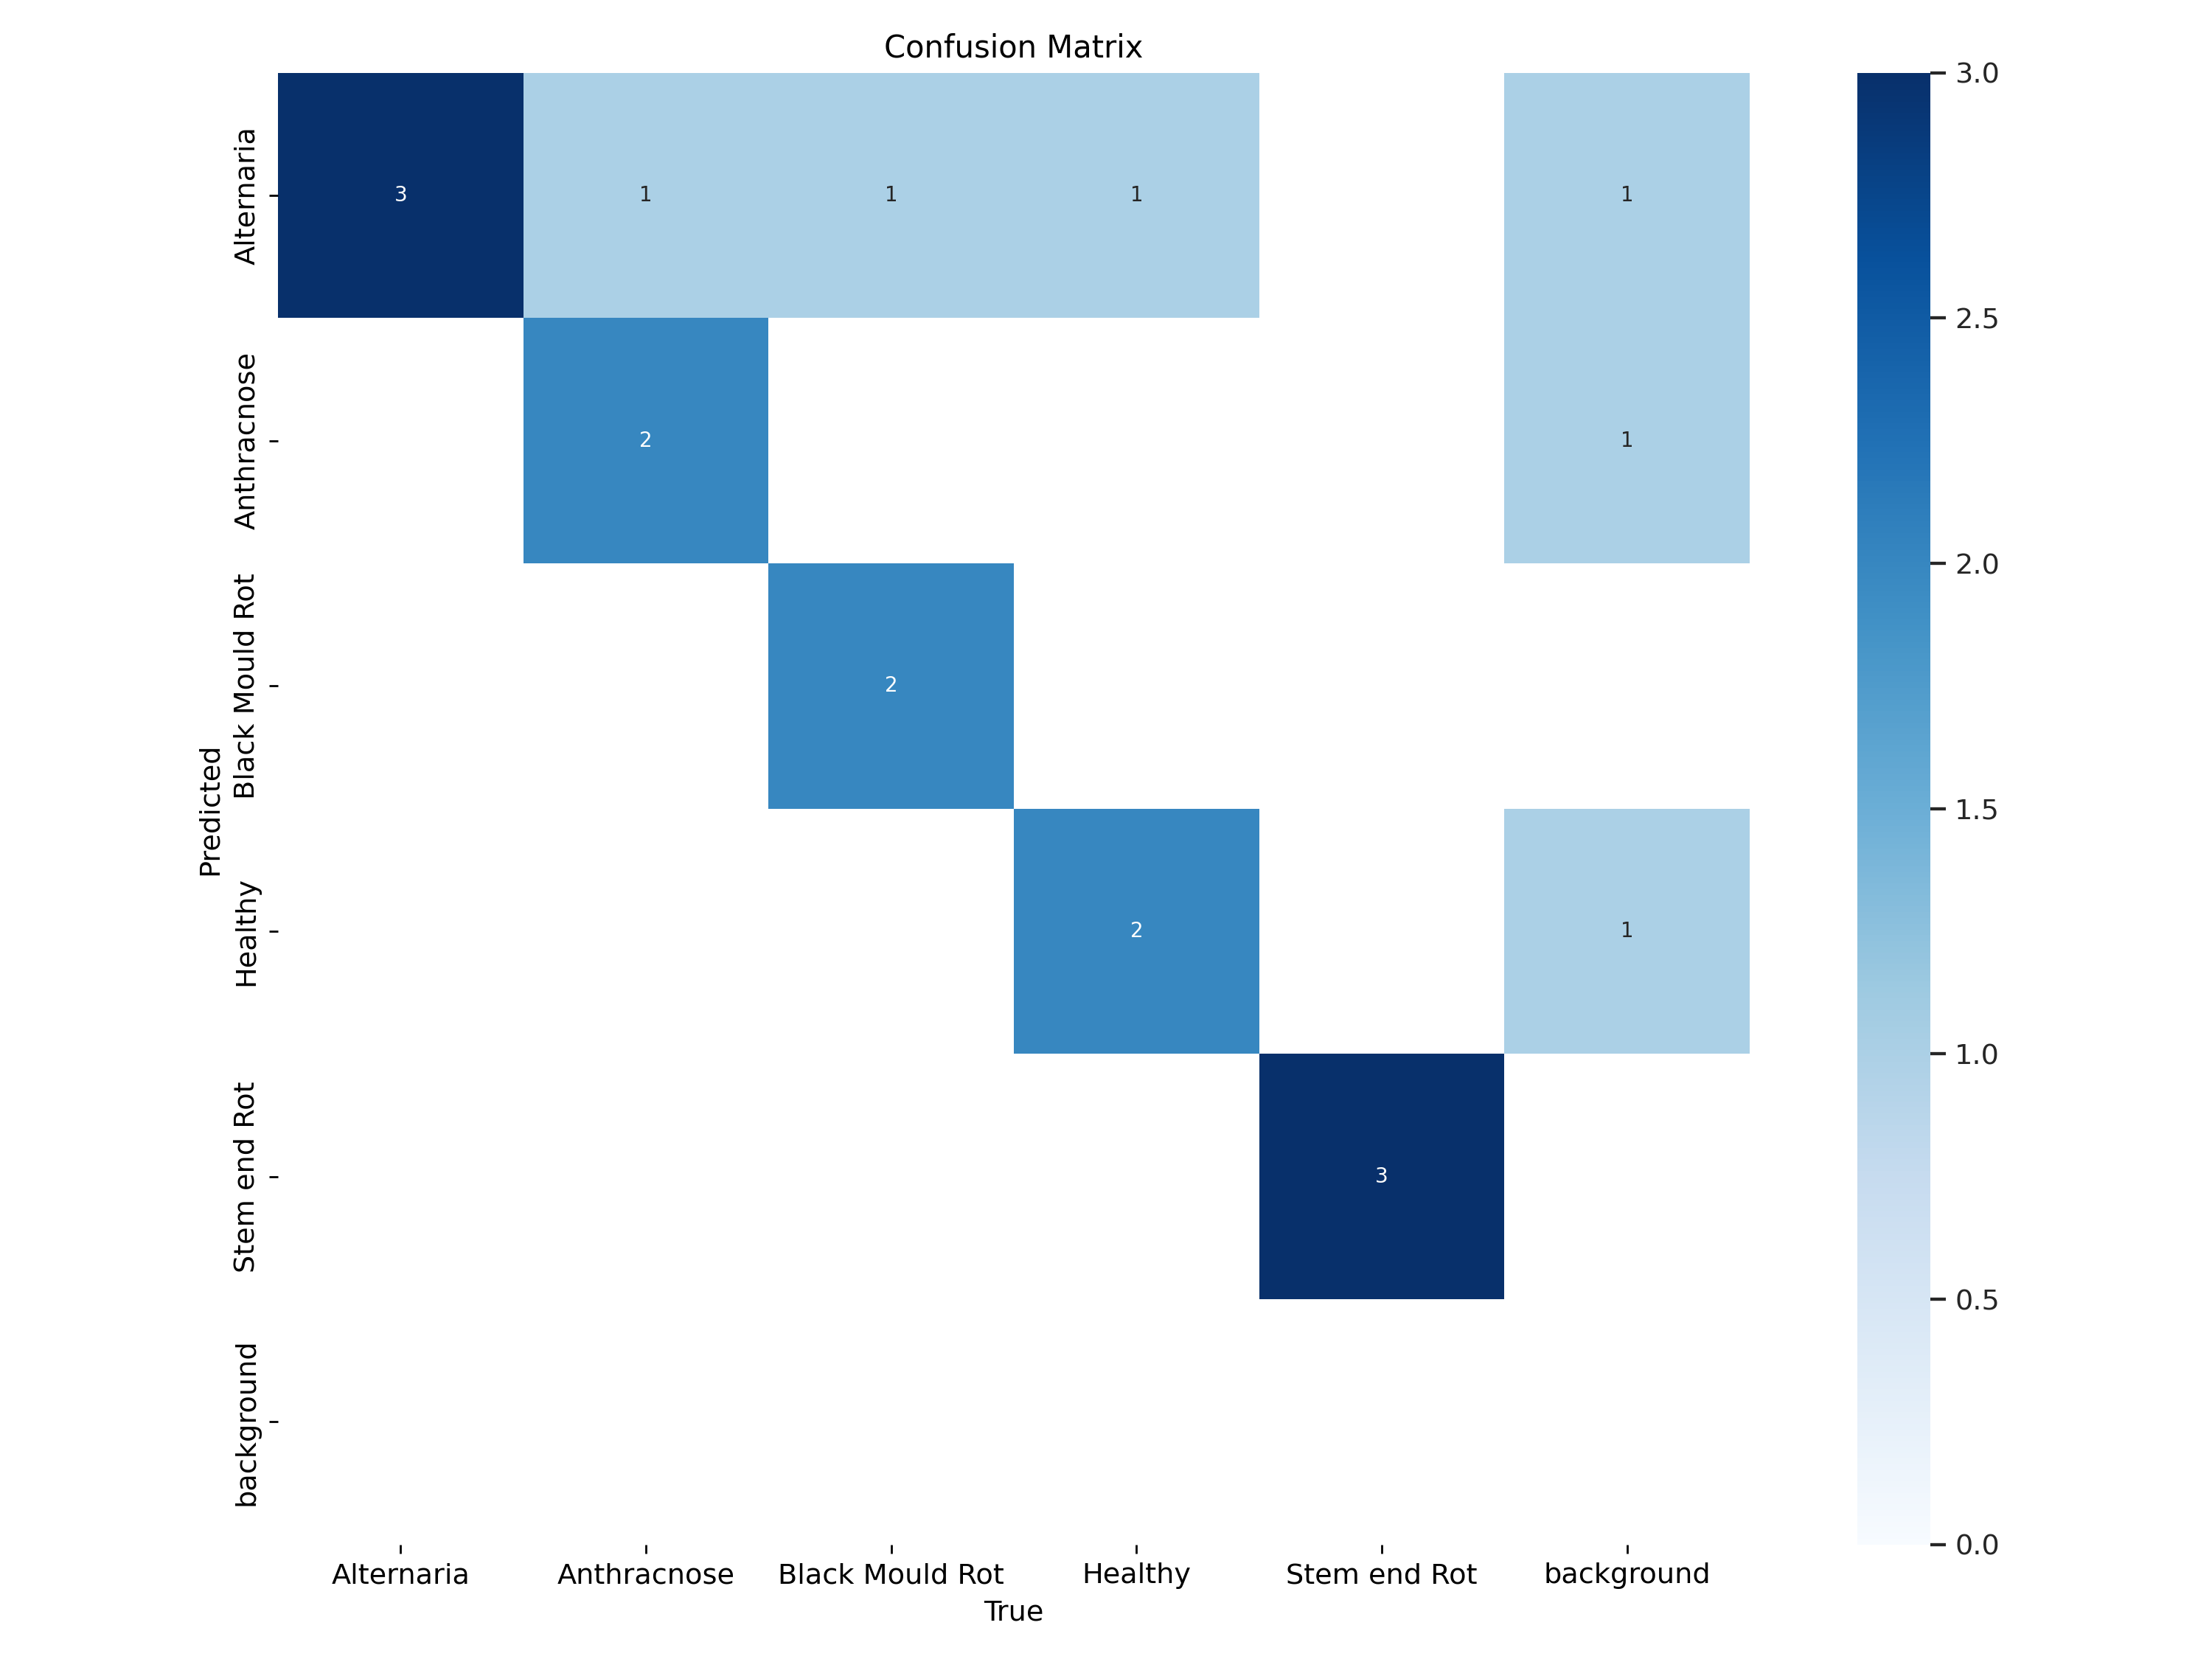

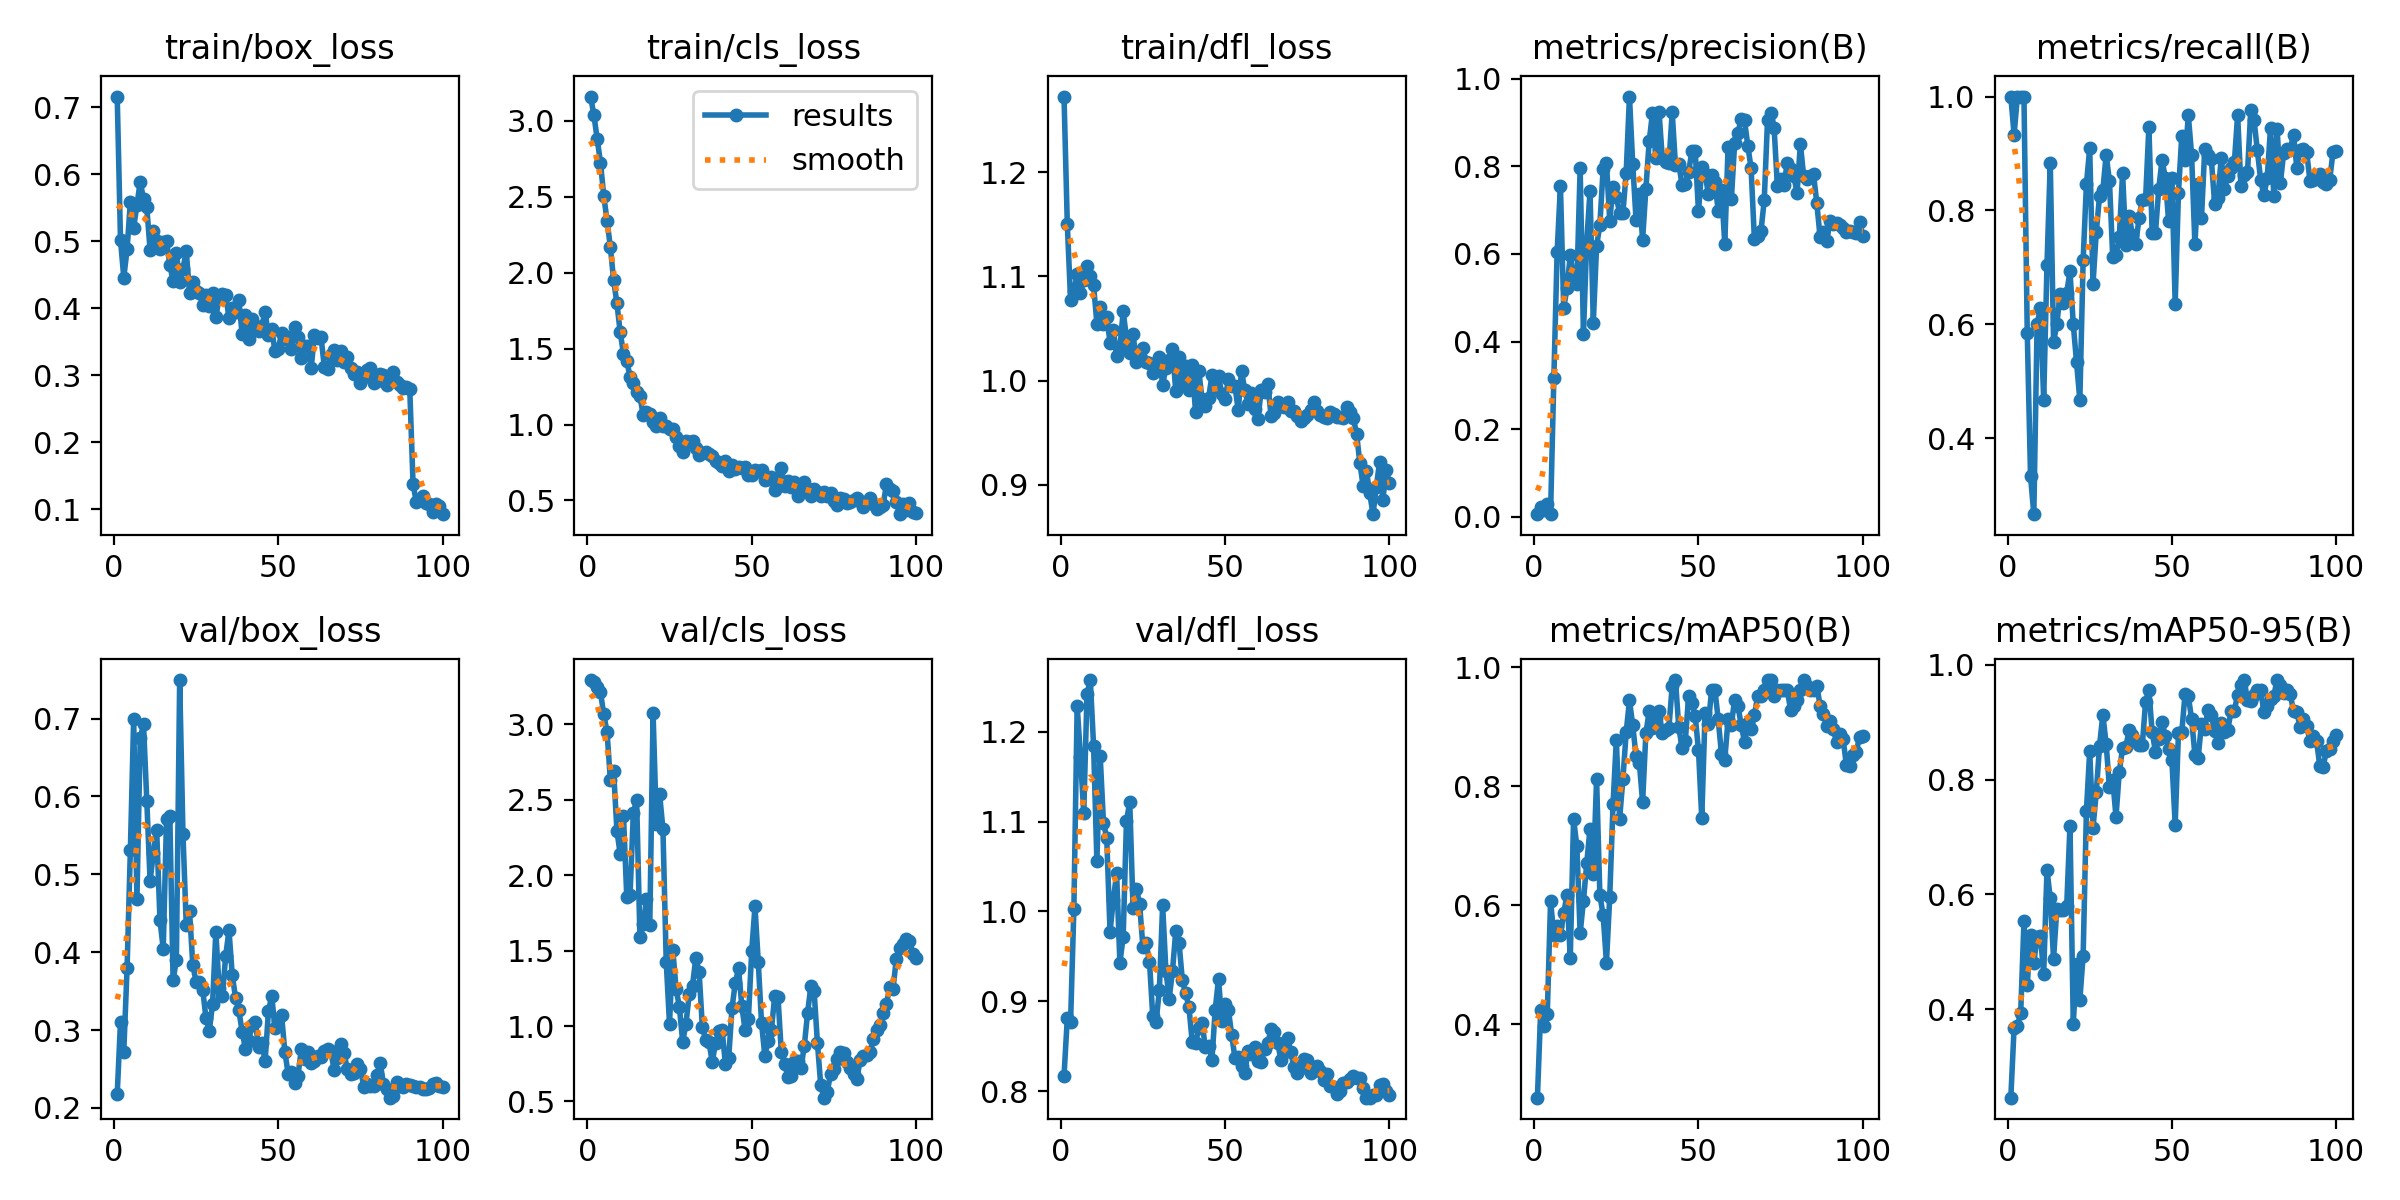

In [ ]:
from IPython.display import Image, display

display(Image(filename="runs/detect/train/confusion_matrix.png", width=700))
display(Image(filename="runs/detect/train/results.png", width=900))

## 5. ทดสอบโมเดลกับชุด Validation

In [ ]:
!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data="{dataset.location}/data.yaml"

Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /content/Mango-1/valid/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% 15/15 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  1.57it/s]
                   all         15         15      0.777      0.943      0.979      0.974
            Alternaria          3          3      0.396          1      0.995      0.995
           Anthracnose          3          3      0.977          1      0.995      0.995
       Black Mould Rot          3          3          1      0.948      0.995      0.995
               Healthy          3          3      0.692      0.767      0.913      0.888
          Stem end Rot          3          3       0.82          1      0.995      0.995
Speed: 0.4ms preprocess, 15.2ms inference, 0.0ms loss, 7.7

## 6. (ทางเลือก) อัปโหลดผลเทรนกลับขึ้น Roboflow

ทำให้ใช้โมเดลนี้ deploy หรือทดสอบผ่าน Roboflow ได้

In [ ]:
version.deploy(model_type="yolov11", model_path="runs/detect/train/")

Inferred model size 'yolov11n' from the checkpoint architecture (model_type was 'yolov11').
View the status of your deployment at: https://app.roboflow.com/project-reai/mango-dlqbi/1
Share your model with the world at: https://universe.roboflow.com/project-reai/mango-dlqbi/model/1


## 7. (ทางเลือก) ดาวน์โหลดน้ำหนักโมเดลกลับเครื่อง

In [ ]:
from google.colab import files

files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. (ทางเลือก) เปิดกล้องรันโมเดลแบบสด (Webcam Inference)

Colab ไม่สามารถเข้าถึงกล้องของเครื่องได้โดยตรง ต้องใช้ JavaScript ผ่านเบราว์เซอร์เพื่อสตรีมภาพจากเว็บแคมแบบต่อเนื่อง แล้วส่งแต่ละเฟรมมารันโมเดล YOLO ที่เพิ่งเทรนเสร็จ (`runs/detect/train/weights/best.pt`) วนลูปไปเรื่อยๆ เพื่อให้เห็นผลตรวจจับแบบสด (near real-time)

กด Run เซลล์ถัดไป (คำอธิบาย + ฟังก์ชัน) แล้วรันเซลล์ลูปตรวจจับ อนุญาตให้เบราว์เซอร์ใช้กล้อง — ผลตรวจจับจะแสดงทับวิดีโอสดไปเรื่อยๆ **คลิกที่วิดีโอเพื่อหยุดลูป**

> หมายเหตุ: ความเร็วขึ้นอยู่กับ latency ของการส่งภาพ base64 ไป-กลับระหว่างเบราว์เซอร์กับ Python runtime (ไม่ใช่วิดีโอสตรีมจริงแบบ WebRTC) เพื่อให้ลื่นขึ้นเซลล์นี้ลดขนาดเฟรมเหลือ 480x360, ลด JPEG quality ทั้งขาไป-กลับ, รันโมเดลที่ `imgsz=320` และใช้ fp16 (`half=True`) อัตโนมัติถ้ามี GPU — ปรับค่า `IMG_SIZE`/`JPEG_QUALITY` ในเซลล์ลูปได้ตามต้องการ (ค่าน้อยลง = เร็วขึ้นแต่แม่นน้อยลง)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np

def video_stream():
    js = Javascript('''
        var video;
        var div = null;
        var stream;
        var captureCanvas;
        var imgElement;
        var labelElement;
        var pendingResolve = null;
        var shutdown = false;

        function removeDom() {
            stream.getVideoTracks()[0].stop();
            video.remove();
            div.remove();
            video = null;
            div = null;
            stream = null;
            imgElement = null;
            captureCanvas = null;
            labelElement = null;
        }

        function onAnimationFrame() {
            if (!shutdown) {
                window.requestAnimationFrame(onAnimationFrame);
            }
            if (pendingResolve) {
                var result = "";
                if (!shutdown) {
                    captureCanvas.getContext('2d').drawImage(video, 0, 0, 480, 360);
                    result = captureCanvas.toDataURL('image/jpeg', 0.6);
                }
                var lp = pendingResolve;
                pendingResolve = null;
                lp(result);
            }
        }

        async function createDom() {
            if (div !== null) {
                return stream;
            }

            div = document.createElement('div');
            div.style.border = '2px solid black';
            div.style.padding = '3px';
            div.style.width = '100%';
            div.style.maxWidth = '480px';
            document.body.appendChild(div);

            const modelOut = document.createElement('div');
            modelOut.innerHTML = "<span>สถานะ: </span>";
            labelElement = document.createElement('span');
            labelElement.innerText = 'กำลังเริ่มกล้อง...';
            labelElement.style.fontWeight = 'bold';
            modelOut.appendChild(labelElement);
            div.appendChild(modelOut);

            video = document.createElement('video');
            video.style.display = 'block';
            video.width = div.clientWidth - 6;
            video.setAttribute('playsinline', '');
            video.onclick = () => { shutdown = true; };
            stream = await navigator.mediaDevices.getUserMedia({video: {facingMode: "environment", width: 480, height: 360}});
            div.appendChild(video);

            imgElement = document.createElement('img');
            imgElement.style.position = 'absolute';
            imgElement.style.zIndex = 1;
            imgElement.onclick = () => { shutdown = true; };
            div.appendChild(imgElement);

            const instruction = document.createElement('div');
            instruction.innerHTML = '<span style="color: red; font-weight: bold;">คลิกที่วิดีโอเพื่อหยุด</span>';
            div.appendChild(instruction);
            instruction.onclick = () => { shutdown = true; };

            video.srcObject = stream;
            await video.play();

            captureCanvas = document.createElement('canvas');
            captureCanvas.width = 480;
            captureCanvas.height = 360;
            window.requestAnimationFrame(onAnimationFrame);

            return stream;
        }

        async function stream_frame(label, imgData) {
            if (shutdown) {
                removeDom();
                shutdown = false;
                return '';
            }

            stream = await createDom();

            if (label != "") {
                labelElement.innerHTML = label;
            }

            if (imgData != "") {
                var videoRect = video.getClientRects()[0];
                imgElement.style.top = videoRect.top + "px";
                imgElement.style.left = videoRect.left + "px";
                imgElement.style.width = videoRect.width + "px";
                imgElement.style.height = videoRect.height + "px";
                imgElement.src = imgData;
            }

            var result = await new Promise(function(resolve, reject) {
                pendingResolve = resolve;
            });
            shutdown = false;

            return result;
        }
        ''')
    display(js)

def video_frame(label, imgData):
    return eval_js('stream_frame("{}", "{}")'.format(label, imgData))

def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    return cv2.imdecode(jpg_as_np, flags=cv2.IMREAD_COLOR)

In [ ]:
import torch
from ultralytics import YOLO

cam_model = YOLO("runs/detect/train/weights/best.pt")
use_gpu = torch.cuda.is_available()
if use_gpu:
    cam_model.to("cuda")

IMG_SIZE = 320       # เล็กลง = เร็วขึ้น (ลองปรับ 256/320/416 ตามความแม่นที่ต้องการ)
JPEG_QUALITY = 60    # คุณภาพภาพที่ส่งกลับไปวาดทับวิดีโอ ยิ่งต่ำยิ่งไว

encode_param = [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]

video_stream()
label_html = 'กำลังตรวจจับ...'
annotated_data = ''
prev_label = None

while True:
    js_reply = video_frame(label_html, annotated_data)
    if not js_reply:
        break  # ผู้ใช้คลิกวิดีโอเพื่อหยุด

    frame = js_to_image(js_reply)
    results = cam_model.predict(
        frame,
        imgsz=IMG_SIZE,
        conf=0.4,
        half=use_gpu,
        device=0 if use_gpu else "cpu",
        verbose=False,
    )
    annotated = results[0].plot()  # เฟรม BGR ที่วาดกล่องตรวจจับแล้ว

    _, buffer = cv2.imencode('.jpg', annotated, encode_param)
    annotated_data = 'data:image/jpeg;base64,' + b64encode(buffer).decode('utf-8')

    names = [cam_model.names[int(b.cls)] for b in results[0].boxes]
    new_label = f'ตรวจพบ: {", ".join(names)}' if names else 'ไม่พบวัตถุ'
    label_html = new_label if new_label != prev_label else ''  # อัปเดต DOM เฉพาะตอนข้อความเปลี่ยน
    prev_label = new_label

<IPython.core.display.Javascript object>

## 9. (ทางเลือก) เปิดกล้อง + ตรวจจับ + บอกขนาด object (พิกเซล)

เหมือนเซลล์ข้อ 8 แต่ข้อความสถานะจะบอกขนาดกว้าง x สูงของแต่ละ object เป็นพิกเซล (px) แทนชื่อคลาสอย่างเดียว

> หมายเหตุ: ขนาดที่ได้เป็น **พิกเซลบนเฟรมที่ส่งมา (480x360)** ไม่ใช่ขนาดจริง (cm/mm) เพราะไม่มีข้อมูล calibration กล้อง/ระยะห่าง ถ้าต้องการขนาดจริงต้องรู้ความกว้างจริงของวัตถุอ้างอิงหรือ focal length ของกล้องเพื่อแปลงหน่วย</cell_type>


In [ ]:
import cv2
import torch
from base64 import b64encode
from ultralytics import YOLO

size_model = YOLO("runs/detect/train/weights/best.pt")

use_gpu = torch.cuda.is_available()
if use_gpu:
    size_model.to("cuda")

IMG_SIZE = 320
JPEG_QUALITY = 60

encode_param = [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]

video_stream()

label_html = 'กำลังตรวจจับ...'
annotated_data = ''

while True:
    js_reply = video_frame(label_html, annotated_data)

    if not js_reply:
        break

    frame = js_to_image(js_reply)

    results = size_model.predict(
        frame,
        imgsz=IMG_SIZE,
        conf=0.4,
        half=use_gpu,
        device=0 if use_gpu else "cpu",
        verbose=False,
    )

    result = results[0]

    # ให้ YOLO วาด bounding box ก่อน
    annotated = result.plot()

    sizes = []

    # วาดขนาด object เพิ่มลงบนภาพ
    for box in result.boxes:

        x1, y1, x2, y2 = box.xyxy[0].cpu().tolist()

        x1 = int(x1)
        y1 = int(y1)
        x2 = int(x2)
        y2 = int(y2)

        w_px = x2 - x1
        h_px = y2 - y1

        cls_id = int(box.cls[0].item())
        class_name = size_model.names[cls_id]

        size_text = f"{w_px} x {h_px} px"

        sizes.append(
            f"{class_name}: {w_px}x{h_px}px"
        )

        # ตำแหน่ง text ใต้ bounding box ด้านบนเล็กน้อย
        text_x = x1
        text_y = max(y2 - 5, 20)

        # วาด background ให้ text อ่านง่าย
        (text_w, text_h), baseline = cv2.getTextSize(
            size_text,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            1
        )

        cv2.rectangle(
            annotated,
            (text_x, text_y - text_h - 5),
            (text_x + text_w + 5, text_y + baseline),
            (0, 0, 0),
            -1
        )

        cv2.putText(
            annotated,
            size_text,
            (text_x + 2, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    # encode ภาพหลังจากวาด size แล้ว
    _, buffer = cv2.imencode(
        '.jpg',
        annotated,
        encode_param
    )

    annotated_data = (
        'data:image/jpeg;base64,'
        + b64encode(buffer).decode('utf-8')
    )

    # แสดงข้อมูลด้านบนด้วย
    if sizes:
        label_html = 'ตรวจพบ: ' + ', '.join(sizes)
    else:
        label_html = 'ไม่พบวัตถุ'

<IPython.core.display.Javascript object>

MessageError: TypeError: Cannot read properties of undefined (reading 'style')